# GulfLink Docket - EDA 

Docket: `MARAD-2019-0093` (Texas GulfLink Deepwater Port)


## 1. Setup



In [1]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.max_columns', 100)


In [3]:
# Locate the raw docket snapshot.
# Not committed to the repository (see data/README.md for provenance and
# how to obtain it). Place it in data/ or beside this notebook.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CANDIDATE_INPUTS = [
    REPO_ROOT / 'data' / 'raw_docket_metadata.csv',
    REPO_ROOT / 'data' / 'raw_docket_metadata.csv.gz',
    Path.cwd() / 'raw_docket_metadata.csv',
]

INPUT = next((path for path in CANDIDATE_INPUTS if path.exists()), None)
if INPUT is None:
    raise FileNotFoundError(
        'Could not find raw_docket_metadata.csv. Expected one of:\n  '
        + '\n  '.join(str(p) for p in CANDIDATE_INPUTS)
        + '\nSee data/README.md for how to obtain it.'
    )

df = pd.read_csv(INPUT, low_memory=False)
print(f'Loaded: {INPUT}')
print(f'Shape: {df.shape}')
df.head(2)

Loaded: data/raw_docket_metadata.csv
Shape: (10716, 60)


,Document ID,Agency ID,Docket ID,Tracking Number,Document Type,Posted Date,Is Withdrawn?,Federal Register Number,FR Citation,Title,Comment Start Date,Comment Due Date,Allow Late Comments,Comment on Document ID,Effective Date,Implementation Date,Postmark Date,Received Date,Author Date,Related RIN(s),Authors,CFR,Abstract,Legacy ID,Media,Document Subtype,Exhibit Location,Exhibit Type,Additional Field 1,Additional Field 2,Topics,Duplicate Comments,OMB/PRA Approval Number,Page Count,Page Length,Paper Width,Special Instructions,Source Citation,Start End Page,Subject,First Name,Last Name,City,State/Province,Zip/Postal Code,Country,Organization Name,Submitter Representative,Representative's Address,"Representative's City, State & Zip",Government Agency,Government Agency Type,Comment,Category,Restrict Reason Type,Restrict Reason,Reason Withdrawn,Content Files,Attachment Files,"Display Properties (Name, Label, Tooltip)"
0,MARAD-2019-0093-0001,MARAD,MARAD-2019-0093,NaN,Notice,2019-06-26T04:00Z,False,2019-13638,NaN,"Deepwater Port License Application:Texas GulfLink, LLC",2019-06-26T04:00Z,2022-12-01T04:59:59Z,False,NaN,2022-11-30T05:00Z,NaN,NaN,2019-06-26T04:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Notice of Intent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,30298 - 30300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"https://downloads.regulations.gov/MARAD-2019-0093-0001/content.pdf,https://downloads.regulations.gov/MARAD-2019-0093-0001/content.htm",NaN,"pageCount, Page Count, Number of pages In the content file"
1,MARAD-2019-0093-0002,MARAD,MARAD-2019-0093,1k3-9ap4-1yio,Other,2019-06-27T04:00Z,False,NaN,NaN,Texas Gulf Link - Deepwater Port Application /Appendix,2019-06-27T04:00Z,NaN,False,NaN,NaN,NaN,NaN,2019-06-26T04:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Application,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"https://downloads.regulations.gov/MARAD-2019-0093-0002/attachment_5.pdf,https://downloads.regulations.gov/MARAD-2019-0093-0002/attachmen...",NaN


## 2. Raw docket overview


In [4]:
doc_type_counts = (
    df['Document Type']
    .fillna('Missing')
    .value_counts()
    .rename_axis('document_type')
    .reset_index(name='count')
)

display(doc_type_counts)
print(f"Distinct docket IDs in file: {df['Docket ID'].nunique()}")
print(f"Posted date min: {df['Posted Date'].min()}")
print(f"Posted date max: {df['Posted Date'].max()}")


,document_type,count
0,Public Submission,10267
1,Other,435
2,Notice,12
3,Supporting & Related Material,2


Distinct docket IDs in file: 1
Posted date min: 2019-06-26T04:00Z
Posted date max: 2025-02-18T05:00Z


## 3. Public submission filter with attachment


In [5]:
pub = df.loc[df['Document Type'].eq('Public Submission')].copy()

pub['comment_raw'] = pub['Comment'].fillna('').astype(str)
pub['comment_text'] = (
    pub['comment_raw']
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
pub['comment_length'] = pub['comment_text'].str.len()

pub['attachment_files_raw'] = pub['Attachment Files'].fillna('').astype(str).str.strip()
pub['has_attachment'] = pub['attachment_files_raw'].ne('')
pub['attachment_count'] = pub['attachment_files_raw'].map(
    lambda x: 0 if not x else len([item for item in x.split(',') if item.strip()])
)
pub['has_inline_text'] = pub['comment_length'].gt(0)

pub['keep_for_analysis'] = pub['comment_length'].ge(20) | pub['has_attachment']
analysis_df = pub.loc[pub['keep_for_analysis']].copy()
dropped_df = pub.loc[~pub['keep_for_analysis']].copy()

analysis_df['submission_source'] = np.select(
    [
        analysis_df['comment_length'].ge(20) & ~analysis_df['has_attachment'],
        analysis_df['comment_length'].ge(20) & analysis_df['has_attachment'],
        analysis_df['comment_length'].lt(20) & analysis_df['has_attachment'],
    ],
    [
        'Inline only',
        'Inline + attachment',
        'Attachment only / see attached',
    ],
    default='Other',
)

print(f'Public submissions: {len(pub):,}')
print(f'Retained for analysis: {len(analysis_df):,}')
print(f'Dropped as too short and no attachment: {len(dropped_df):,}')
print(
    'Retained attachment-only submissions: '
    f"{(analysis_df['submission_source'] == 'Attachment only / see attached').sum():,}"
)

analysis_df['submission_source'].value_counts()


Public submissions: 10,267
Retained for analysis: 10,195
Dropped as too short and no attachment: 72
Retained attachment-only submissions: 245


submission_source
Inline only                       9874
Attachment only / see attached     245
Inline + attachment                 76
Name: count, dtype: int64

In [6]:
analysis_df.loc[
    analysis_df['submission_source'].eq('Attachment only / see attached'),
    ['Document ID', 'Title', 'comment_text', 'Attachment Files']
].head(10)


,Document ID,Title,comment_text,Attachment Files
272,MARAD-2019-0093-0273,Comments of Brandt Mannchen,Attached,https://downloads.regulations.gov/MARAD-2019-0093-0273/attachment_1.pdf
1763,MARAD-2019-0093-10694,File09-04-2024-104612-1,See Attached,https://downloads.regulations.gov/MARAD-2019-0093-10694/attachment_1.pdf
1765,MARAD-2019-0093-10696,Comment from BT,See Attached,https://downloads.regulations.gov/MARAD-2019-0093-10696/attachment_1.pdf
1766,MARAD-2019-0093-10697,Comment from Laura J,See Attached,https://downloads.regulations.gov/MARAD-2019-0093-10697/attachment_1.pdf
1767,MARAD-2019-0093-10698,Comment,See Attached,https://downloads.regulations.gov/MARAD-2019-0093-10698/attachment_1.pdf
1768,MARAD-2019-0093-10699,Comment from LB,See Attached,https://downloads.regulations.gov/MARAD-2019-0093-10699/attachment_1.pdf
1770,MARAD-2019-0093-10700,Comment from NH,See Attached,https://downloads.regulations.gov/MARAD-2019-0093-10700/attachment_1.pdf
1771,MARAD-2019-0093-10701,Comment from David G,See Attached,https://downloads.regulations.gov/MARAD-2019-0093-10701/attachment_1.pdf
1772,MARAD-2019-0093-10702,"Comments from Maliya Hall, Alice Frank, Tanya Davis, Sandra Beverly",See Attached,https://downloads.regulations.gov/MARAD-2019-0093-10702/attachment_1.pdf
1773,MARAD-2019-0093-10703,"Comments from Taelor Hobbs, Barbara White, Ariana Ruiz",See Attached,https://downloads.regulations.gov/MARAD-2019-0093-10703/attachment_1.pdf


## 4. Metadata cleaning



In [7]:
US_STATE_MAP = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'DC': 'District Of Columbia', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii',
    'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine',
    'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska',
    'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico',
    'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas',
    'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'PR': 'Puerto Rico', 'VI': 'Virgin Islands', 'GU': 'Guam'
}
FULL_STATE_LOOKUP = {value.upper(): value for value in US_STATE_MAP.values()}

def normalize_state(value):
    if pd.isna(value):
        return np.nan
    text = re.sub(r'\s+', ' ', str(value)).strip()
    if not text:
        return np.nan
    token = text.upper().replace('.', '')
    if token in US_STATE_MAP:
        return US_STATE_MAP[token]
    if token in FULL_STATE_LOOKUP:
        return FULL_STATE_LOOKUP[token]
    return text.title()

def normalize_org(value):
    if pd.isna(value):
        return np.nan
    text = re.sub(r'\s+', ' ', str(value)).strip()
    if not text:
        return np.nan
    text = text.replace('&', ' and ')
    text = re.sub(r'[^A-Za-z0-9 ]+', '', text)
    text = re.sub(r'incorporated', 'inc', text, flags=re.IGNORECASE)
    text = re.sub(r'corporation', 'corp', text, flags=re.IGNORECASE)
    text = re.sub(r'company', 'co', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.title() if text else np.nan

analysis_df['state_clean'] = analysis_df['State/Province'].map(normalize_state)
analysis_df['organization_clean'] = analysis_df['Organization Name'].map(normalize_org)
analysis_df['posted_date'] = pd.to_datetime(analysis_df['Posted Date'], errors='coerce', utc=True)
analysis_df['posted_month'] = analysis_df['posted_date'].dt.tz_localize(None).dt.to_period('M').astype(str)
analysis_df['posted_year'] = analysis_df['posted_date'].dt.year

print(f"Distinct cleaned states: {analysis_df['state_clean'].nunique(dropna=True)}")
print(f"Distinct cleaned organizations: {analysis_df['organization_clean'].nunique(dropna=True)}")
analysis_df[['State/Province', 'state_clean', 'Organization Name', 'organization_clean']].head(10)


Distinct cleaned states: 63
Distinct cleaned organizations: 40


,State/Province,state_clean,Organization Name,organization_clean
3,TX,Texas,NaN,NaN
4,NaN,NaN,NaN,NaN
5,TX,Texas,NaN,NaN
6,NaN,NaN,Center for Biological Diversity,Center For Biological Diversity
7,NaN,NaN,Center for Biological Diversity,Center For Biological Diversity
8,NaN,NaN,Center for Biological Diversity,Center For Biological Diversity
9,NaN,NaN,Center for Biological Diversity,Center For Biological Diversity
10,NaN,NaN,Center for Biological Diversity,Center For Biological Diversity
11,NaN,NaN,Center for Biological Diversity,Center For Biological Diversity
12,NaN,NaN,Center for Biological Diversity,Center For Biological Diversity


## 5. Duplicate comments and template families

`exact_form_letter` flags duplicates.
`template_family` cluster comments that differ only by light edits (grouping that uses the first 45 content heavy tokens)



In [8]:
STOPWORDS = {
    'the', 'and', 'for', 'that', 'with', 'this', 'from', 'into', 'their', 'there', 'would',
    'could', 'should', 'about', 'have', 'has', 'had', 'are', 'was', 'were', 'been', 'being',
    'not', 'but', 'you', 'your', 'they', 'them', 'our', 'out', 'all', 'any', 'can', 'may',
    'will', 'must', 'its', 'his', 'her', 'she', 'him', 'who', 'what', 'when', 'where', 'why',
    'how', 'also', 'very', 'more', 'most', 'than', 'then', 'just', 'only', 'such', 'because',
    'while', 'which', 'these', 'those', 'each', 'many', 'much', 'over', 'under', 'between',
    'through', 'after', 'before', 'during', 'against', 'again', 'further', 'same', 'some',
    'like', 'been', 'make', 'made', 'make', 'into', 'onto', 'upon', 'here', 'therefore'
}

def canonicalize_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def template_signature(text, max_tokens=45):
    tokens = re.findall(r"[a-z']+", str(text).lower())
    content_tokens = [token for token in tokens if len(token) > 2 and token not in STOPWORDS]
    if not content_tokens:
        return ''
    return ' '.join(content_tokens[:max_tokens])

analysis_df['comment_canonical'] = analysis_df['comment_text'].map(canonicalize_text)
analysis_df['exact_form_letter'] = analysis_df['comment_canonical'].duplicated(keep=False)
analysis_df['template_signature'] = analysis_df['comment_text'].map(template_signature)
analysis_df['template_family'] = analysis_df['template_signature'].duplicated(keep=False) & analysis_df['template_signature'].ne('')

exact_group_map = {
    text: idx + 1
    for idx, text in enumerate(
        analysis_df.loc[analysis_df['comment_canonical'].ne(''), 'comment_canonical'].drop_duplicates()
    )
}
template_group_map = {
    text: idx + 1
    for idx, text in enumerate(
        analysis_df.loc[analysis_df['template_signature'].ne(''), 'template_signature'].drop_duplicates()
    )
}

analysis_df['exact_form_letter_group'] = analysis_df['comment_canonical'].map(exact_group_map)
analysis_df['template_family_id'] = analysis_df['template_signature'].map(template_group_map)

print(f"Exact duplicate signers: {int(analysis_df['exact_form_letter'].sum()):,}")
print(f"Template-family signers: {int(analysis_df['template_family'].sum()):,}")
print(f"Unique normalized inline comments: {analysis_df['comment_canonical'].nunique():,}")


Exact duplicate signers: 3,885
Template-family signers: 8,711
Unique normalized inline comments: 6,551


In [9]:
top_template_families = (
    analysis_df.loc[analysis_df['template_family']]
    .groupby('template_signature')
    .agg(
        n_signers=('Document ID', 'count'),
        sample_text=('comment_text', 'first'),
        has_attachment=('has_attachment', 'max')
    )
    .sort_values('n_signers', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_template_families['sample_text'] = top_template_families['sample_text'].str.slice(0, 220) + '...'
top_template_families


,n_signers,sample_text,has_attachment
0,3470,I am writing to voice my opposition to the Texas GulfLink oil export terminal. The final environmental impact statement released by MARA...,False
1,1814,"I am writing to express opposition to Texas GulfLink LLC's application for a Deepwater Port License from the Maritime Administration, an...",False
2,1279,"The Texas GulfLink project, owned by Sentinel Midstream, aims to transport 1 million barrels of crude oil per day to buyers overseas. Oi...",False
3,482,I am writing to express opposition to Texas GulfLink LLC's application for a Deepwater Port License from the Maritime Administration and...,False
4,275,I urge you to reject the license for the Texas GulfLink oil export terminal. Approving the GulfLink project now would lock in decades of...,False
5,248,"The Texas GulfLink project poses significant environmental, social, and economic risks that far outweigh any potential benefits. Positio...",False
6,242,See Attached...,True
7,240,"NO LICENSE FOR GULF LINK, NOT TODAY, NOT EVER! I send this comment as member of Elders Climate Action and a concerned citizen who is hor...",False
8,84,I would like to express opposition to the Texas GulfLink LLC application for a Deepwater Port License from the Maritime Administration a...,False
9,57,"To whom it may concern, I am writing to urge MARAD to halt the approval of the Texas GulfLink project. The project is projected to emit ...",False


## 6. Baseline topic tagging from inline text

keyword baseline that approximates the dissertation brief's target topic areas.
Attachment only submissions are preserved, but they still need PDF text extraction before they can be topic tagged properly.


In [10]:
TOPIC_PATTERNS = {
    'oil_spill_risk': [r'\boil spill', r'\bdeepwater horizon', r'\bspill risk', r'\bcatastrophic'],
    'climate_emissions': [r'\bclimate change', r'\bgreenhouse gas', r'\bemissions?', r'\bfossil fuel'],
    'air_quality': [r'\bair quality', r'\bair pollution', r'\bozone', r'\bnox\b'],
    'environmental_justice': [r'\benvironmental justice', r'\benvironmental racism', r'\blow-income', r'\bminority communities'],
    'marine_wildlife': [r'\bsea turtle', r'\bmarine mammals?', r'\bdolphin', r'\bwhale', r'\bblack rail', r'\bhabitats?'],
    'fisheries': [r'\bfisher(?:y|ies)', r'\bshrimp', r'\bcommercial fishing', r'\bfishermen'],
    'wetlands_coast': [r'\bwetlands?', r'\bcoastline', r'\berosion', r'\bstorm surge', r'\bsea level rise', r'\bflood'],
    'national_interest': [r'\bnational interest', r'\bnot in the national interest'],
}

inline_topicable = analysis_df['comment_length'].ge(20)

for topic, patterns in TOPIC_PATTERNS.items():
    regex = '|'.join(f'(?:{pattern})' for pattern in patterns)
    analysis_df[topic] = inline_topicable & analysis_df['comment_text'].str.contains(
        regex,
        case=False,
        regex=True,
        na=False,
    )

topic_summary = pd.DataFrame(
    {
        'topic': list(TOPIC_PATTERNS.keys()),
        'mentions': [int(analysis_df[topic].sum()) for topic in TOPIC_PATTERNS.keys()],
    }
).sort_values('mentions', ascending=False)

topic_summary


,topic,mentions
1,climate_emissions,9232
3,environmental_justice,7918
7,national_interest,6612
0,oil_spill_risk,4659
6,wetlands_coast,4476
2,air_quality,4013
4,marine_wildlife,2971
5,fisheries,6


## 7. Baseline argument and request extraction

This section produces simple features for what commenters are asking the agency to do.


In [11]:
oppose_regex = r'\b(?:oppose|opposition|deny|reject|not in the national interest|concerned)\b'
support_regex = r'\b(?:support|approve|in favor|favour)\b'

analysis_df['stance'] = np.select(
    [
        analysis_df['comment_text'].str.contains(oppose_regex, case=False, regex=True, na=False),
        analysis_df['comment_text'].str.contains(support_regex, case=False, regex=True, na=False),
        analysis_df['submission_source'].eq('Attachment only / see attached'),
    ],
    ['Oppose', 'Support', 'Attachment only / unknown'],
    default='Unclear',
)

REQUEST_PATTERNS = {
    'request_deny_or_reject': [r'\bdeny\b', r'\breject\b'],
    'request_more_analysis': [r'\banaly[sz]e\b', r'\bstudy\b', r'\bconsider\b', r'\bevaluate\b'],
    'request_protect_wildlife': [r'\bprotect\b', r'\bhabitat', r'\bsea turtle', r'\bmarine mammals?'],
    'request_address_ej': [r'\benvironmental justice', r'\blow-income', r'\bminority communities'],
}

for column, patterns in REQUEST_PATTERNS.items():
    regex = '|'.join(f'(?:{pattern})' for pattern in patterns)
    analysis_df[column] = analysis_df['comment_text'].str.contains(regex, case=False, regex=True, na=False)

stance_counts = analysis_df['stance'].value_counts(dropna=False)
request_summary = pd.DataFrame(
    {
        'request_feature': list(REQUEST_PATTERNS.keys()),
        'mentions': [int(analysis_df[column].sum()) for column in REQUEST_PATTERNS.keys()],
    }
).sort_values('mentions', ascending=False)

display(stance_counts)
request_summary


stance
Oppose                       7736
Unclear                      1966
Support                       248
Attachment only / unknown     245
Name: count, dtype: int64

,request_feature,mentions
3,request_address_ej,7868
2,request_protect_wildlife,4373
0,request_deny_or_reject,3227
1,request_more_analysis,2546


## 8. EDA visuals


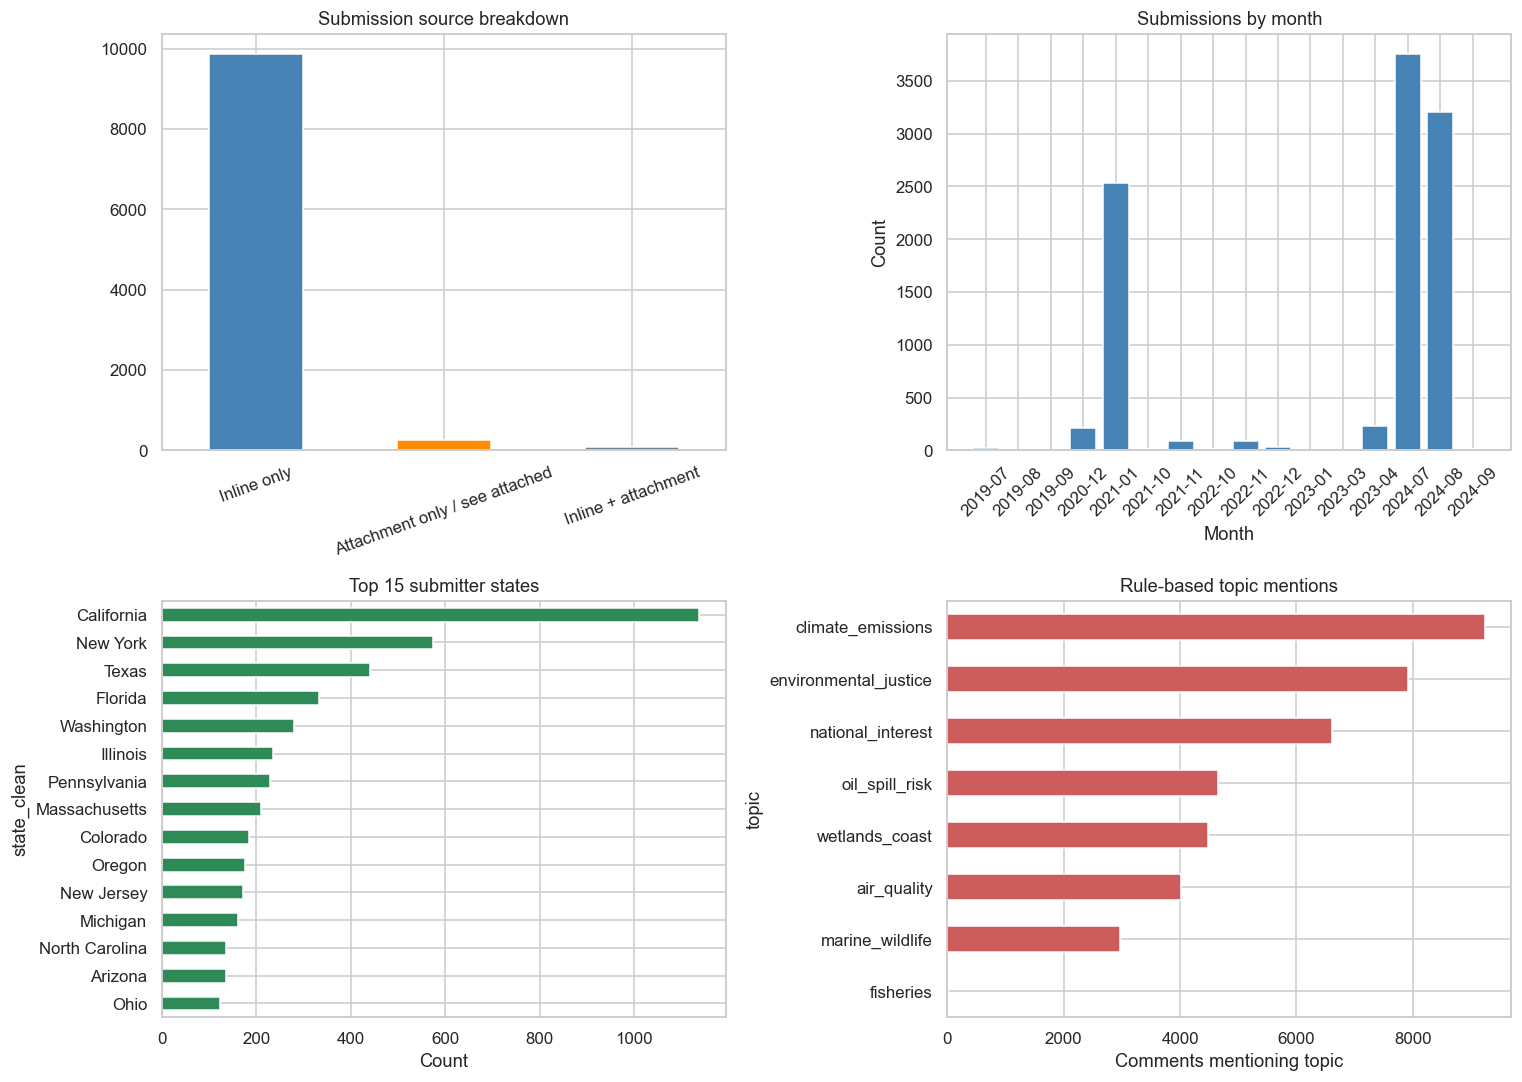

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

analysis_df['submission_source'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'darkorange', 'slategray'])
axes[0, 0].set_title('Submission source breakdown')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=20)

monthly = analysis_df.groupby('posted_month').size().reset_index(name='count').sort_values('posted_month')
axes[0, 1].bar(monthly['posted_month'], monthly['count'], color='steelblue')
axes[0, 1].set_title('Submissions by month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

top_states = analysis_df['state_clean'].value_counts().head(15).sort_values()
top_states.plot(kind='barh', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Top 15 submitter states')
axes[1, 0].set_xlabel('Count')

topic_summary.sort_values('mentions').plot(kind='barh', x='topic', y='mentions', ax=axes[1, 1], color='indianred', legend=False)
axes[1, 1].set_title('Rule-based topic mentions')
axes[1, 1].set_xlabel('Comments mentioning topic')

plt.tight_layout()
plt.show()


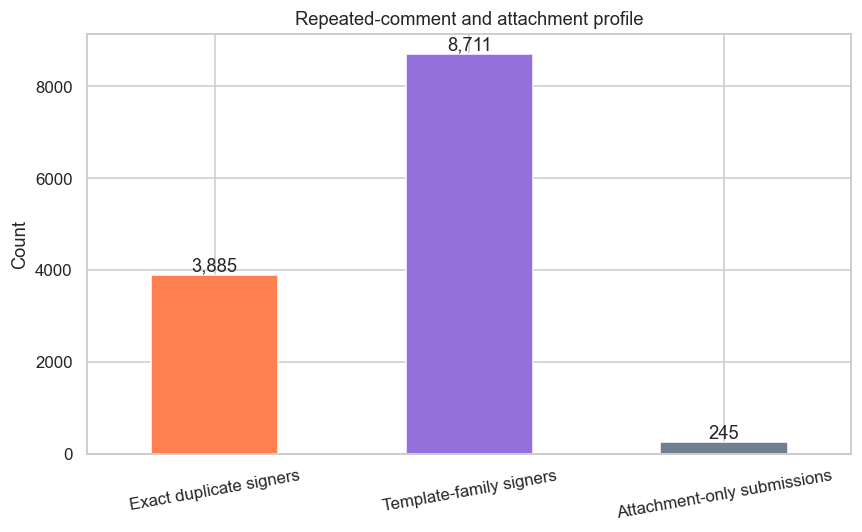

In [13]:
family_breakdown = pd.Series(
    {
        'Exact duplicate signers': int(analysis_df['exact_form_letter'].sum()),
        'Template-family signers': int(analysis_df['template_family'].sum()),
        'Attachment-only submissions': int(analysis_df['submission_source'].eq('Attachment only / see attached').sum()),
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
family_breakdown.plot(kind='bar', ax=ax, color=['coral', 'mediumpurple', 'slategray'])
ax.set_title('Repeated-comment and attachment profile')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=10)
for idx, value in enumerate(family_breakdown.values):
    ax.text(idx, value, f'{value:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


## 9. Export analysis-ready data


In [14]:
export_cols = [
    'Document ID', 'Docket ID', 'Title', 'posted_date', 'posted_month', 'posted_year',
    'First Name', 'Last Name', 'Organization Name', 'organization_clean',
    'City', 'State/Province', 'state_clean', 'Country',
    'comment_text', 'comment_length', 'has_inline_text',
    'has_attachment', 'attachment_count', 'submission_source',
    'exact_form_letter', 'exact_form_letter_group',
    'template_family', 'template_family_id',
    'stance',
    'oil_spill_risk', 'climate_emissions', 'air_quality', 'environmental_justice',
    'marine_wildlife', 'fisheries', 'wetlands_coast', 'national_interest',
    'request_deny_or_reject', 'request_more_analysis', 'request_protect_wildlife', 'request_address_ej',
    'Attachment Files', 'Content Files'
]

export_path = Path.cwd() / 'gulf_link_analysis_ready.csv'
analysis_df[export_cols].to_csv(export_path, index=False)
print(f'Saved analysis-ready file to: {export_path}')


Saved analysis-ready file to: data/gulf_link_analysis_ready.csv


## 10. Summary



In [15]:
summary = {
    'Public submissions (raw)': len(pub),
    'Rows retained for analysis': len(analysis_df),
    'Attachment-only submissions retained': int(analysis_df['submission_source'].eq('Attachment only / see attached').sum()),
    'Exact duplicate signers': int(analysis_df['exact_form_letter'].sum()),
    'Template-family signers': int(analysis_df['template_family'].sum()),
    'Comments with attachments': int(analysis_df['has_attachment'].sum()),
    'Cleaned states represented': int(analysis_df['state_clean'].nunique(dropna=True)),
    'Cleaned organizations represented': int(analysis_df['organization_clean'].nunique(dropna=True)),
    'Date range start': str(analysis_df['posted_date'].min().date()),
    'Date range end': str(analysis_df['posted_date'].max().date()),
}

for key, value in summary.items():
    print(f'{key:35s}: {value}')


Public submissions (raw)           : 10267
Rows retained for analysis         : 10195
Attachment-only submissions retained: 245
Exact duplicate signers            : 3885
Template-family signers            : 8711
Comments with attachments          : 321
Cleaned states represented         : 63
Cleaned organizations represented  : 40
Date range start                   : 2019-07-03
Date range end                     : 2024-09-12
